# ICMS 150 (April 4)

- **Combined_Pattern_Registrations.pkl**: including electrical stimulation pattern informations, the same format as the one I shared before with you.
- **All_Shank_Spk_Vecs.npy**: spiking events from each neuron. The same format as previous. Sampling frequency: 30K
- **VStim_Onset_TS.npy**: the onset timestamps of each visual stimulus trials. NOTE: These are recorded at a different sampling frequency, which is 1K. DO REMEMBER to align data in 2. and 3., they're not written under the same clock (due to hardware setup).
- **VStim_Labels.npy**: the orientation degree for each visual stimulus trials. Each degree should have 100 trials.


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 100 oracle samples repeating 10 times


In [1]:
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2


all_spikes = np.load("data/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json("data/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load("data/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load("data/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

In [2]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 72, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 72, 50)


In [5]:
# Pretend the integration window is 600ms, so scale up sum_responses by 600/500 = 1.2 to get firing rates in Hz (spikes/s)
INTEGRATION_MS = 600
scaling_factor = INTEGRATION_MS / STIM_MS
sum_responses *= scaling_factor
print(f"Scaled sum_responses to firing rates (Hz) using factor {scaling_factor:.2f} for {INTEGRATION_MS} ms integration window")

Scaled sum_responses to firing rates (Hz) using factor 1.20 for 600 ms integration window


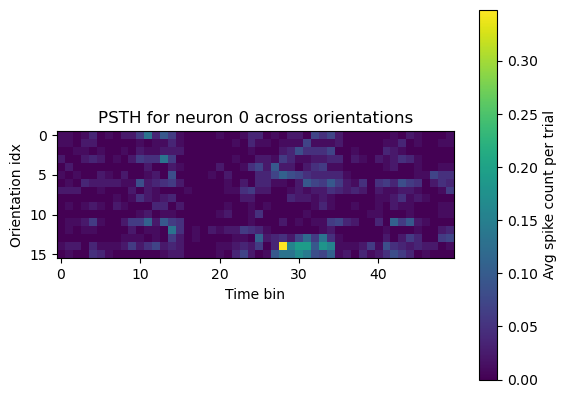

In [6]:
plt.imshow(sum_responses[:, 3, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title("PSTH for neuron 0 across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

In [7]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA
# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1) # (n_orientations, n_neurons)
mean_vec = X.mean(axis=0, keepdims=True)  # (1, n_neurons)

pca3 = PCA(n_components=2)
pca3.fit(X)

proj, _ = np.linalg.qr(np.array([
    mean_vec[0],
    pca3.components_[0],
    pca3.components_[1],
]).T)  # (n_neurons, 3)

coords = X @ proj  # (n_orientations, 3)

colors = [f'hsl({int(o)}, 80%, 50%)' for o in visual_orientation_degs]


# map orientations to 0-360 by doubling (so 0=180 both map to 0/360)
doubled = (np.array(visual_orientation_degs) * 2) % 360


fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))

fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.show()


In [ ]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
DATADIR = 'data'
pattern_df_raw = read_pattern_json(f'{DATADIR}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 72
Unique patterns: 3100, Total trials: 4000


In [80]:
from numpy.lib.stride_tricks import sliding_window_view
from collections import defaultdict
from torch import mode

WINDOW_SIZE = 300  # ms
SPIKE_LATENCY = 0          # ms
OVERLAPS = False
MODE = "step"              # "pulse" or "step"

spike_accum = []
stim_by_pattern = []            # pname -> X (identical across trials)
plotted = False

for j, timing_idx in enumerate(list(spike_responses.keys())):
    if timing_idx not in test_indices: # skip oracle
        continue

    spk   = spike_responses[timing_idx]
    pname = timing_to_pattern[timing_idx]
    win   = spk[:, SPIKE_LATENCY:SPIKE_LATENCY + MAX_TIME_MS]
    stim  = pattern_stims[pname]
    pol   = pattern_polarities[pname]
    signed_stim = stim * pol

    if MODE == "step":
        if WINDOW_SIZE % 60 != 0:
            raise ValueError("For step mode, WINDOW_SIZE must be a multiple of 60ms.")
        delay_mode_to_lridx = {-1: 0, 0: 1, 1:2, 2: 3} # this is the offset of the feature for channel c and delay mode lridx
        stim_one_hot = np.zeros((n_stim_channels * 4, signed_stim.shape[1] // 60))
        for step in range(0, signed_stim.shape[1], 60):
            for ch in range(n_stim_channels):
                delay_mode = None
                if signed_stim[ch, step] == 3:
                    delay_mode = 0
                elif signed_stim[ch, step] == -3 and signed_stim[ch, step + 10] == 3:
                    delay_mode = 2
                elif signed_stim[ch, step + 10] == 3:
                    delay_mode = 1
                elif signed_stim[ch, step] == -3:
                    delay_mode = -1
                if delay_mode is not None:
                    stim_one_hot[ch * 4 + delay_mode_to_lridx[delay_mode], step // 60] = 1
    elif MODE == "pulse":
        stim_one_hot = np.zeros((n_stim_channels * n_amplitudes, win.shape[1]))
        for ch in range(n_stim_channels):
            for a_idx, amp_val in enumerate([-3, 3]):
                stim_one_hot[ch * n_amplitudes + a_idx, :] = (signed_stim[ch, :] == amp_val)

    if OVERLAPS:
        spk_view = sliding_window_view(win, window_shape=WINDOW_SIZE, axis=1)
        Y = spk_view.sum(axis=-1).T
        if MODE == "step":
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE // 60, axis=1)
            X = stim_view.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
        else:
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE, axis=1)
            X = stim_view.sum(axis=-1).T
    else:
        Y = win.reshape(n_neurons, -1, WINDOW_SIZE).sum(axis=-1).T 
        if MODE == "step":
            X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
        else:
            X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE).sum(axis=-1).T
    spike_accum.append(Y)
    stim_by_pattern.append(X)

all_spikes = np.vstack(spike_accum) - np.mean(np.vstack(spike_accum), axis=0) 
all_stims  = np.vstack(stim_by_pattern)

print (f"Final dataset shapes - Spikes: {all_spikes.shape}, Stims: {all_stims.shape}")

ValueError: cannot reshape array of size 51840 into shape (72,newaxis,300)

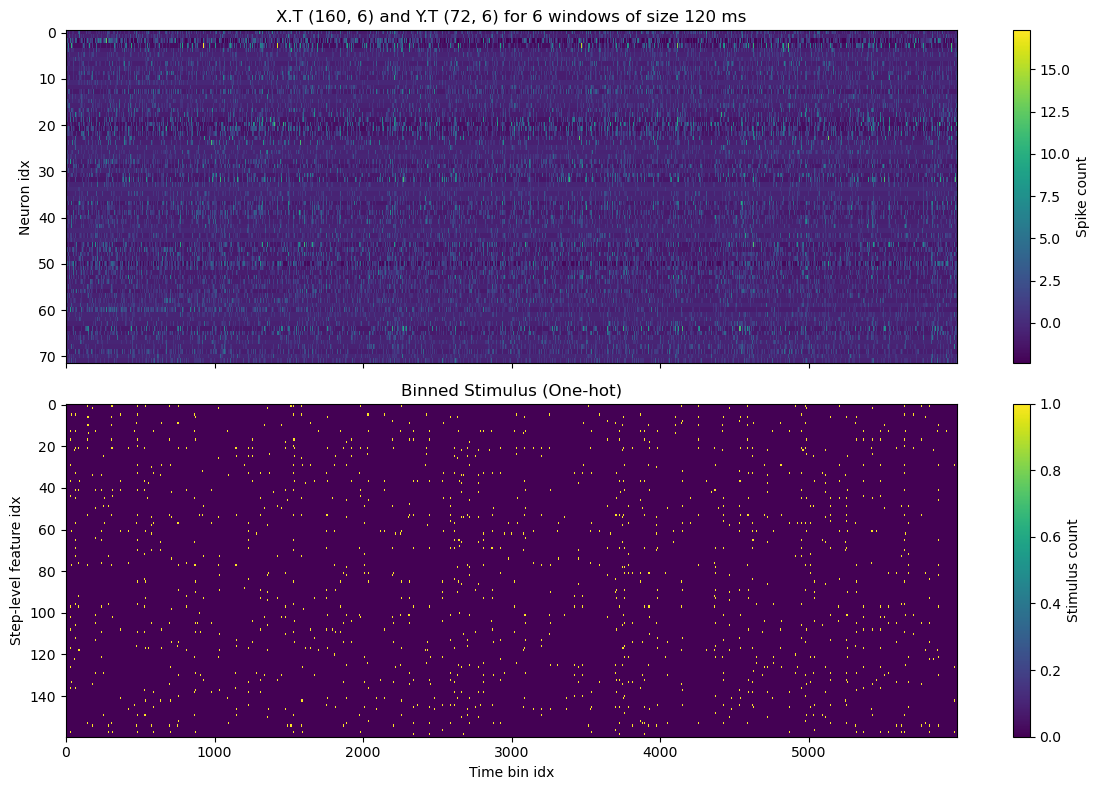

In [78]:
f, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
plt.title(f"Pattern: {pname} (Timing idx: {timing_idx})")
ax[0].imshow(all_spikes.T, aspect='auto', interpolation='nearest')
ax[0].set_ylabel("Neuron idx")
ax[0].set_title(f"X.T {X.T.shape} and Y.T {Y.T.shape} for {MAX_TIME_MS//WINDOW_SIZE} windows of size {WINDOW_SIZE} ms")
ax[1].imshow(all_stims.T, aspect='auto', interpolation='nearest')
ax[1].set_xlabel("Time bin idx")
ax[1].set_ylabel("Step-level feature idx" if MODE == "step" else "Pulse-level feature idx")
ax[1].set_title("Binned Stimulus (One-hot)")
plt.tight_layout()
plt.colorbar(ax[0].images[0], ax=ax[0], label='Spike count')
plt.colorbar(ax[1].images[0], ax=ax[1], label='Stimulus count')
plt.show()

In [79]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error

reg = LinearRegression(fit_intercept=False).fit(all_stims, all_spikes)
# reg = Ridge(alpha=10).fit(all_stims, all_spikes)  # add small constant to avoid log(0)
Y_pred = reg.predict(all_stims)
# 2. Calculate R^2 for each neuron
# multioutput='raw_values' returns an array of R^2 scores, one per neuron
r2_values = r2_score(all_spikes, Y_pred, multioutput='raw_values')

# 3. Calculate Mean Squared Error (MSE) per neuron
mse_values = mean_squared_error(all_spikes, Y_pred, multioutput='raw_values')

print(f"Average R^2 across all neurons: {np.mean(r2_values):.4f}")
print(f"Average MSE across all neurons: {np.mean(mse_values):.4f}")

Average R^2 across all neurons: 0.1421
Average MSE across all neurons: 1.3551


In [75]:
spike_accum = []
stim_by_pattern = []
WINDOW_SIZE = 720 
for j, timing_idx in enumerate(list(spike_responses.keys())):
    if timing_idx not in test_indices: # skip oracle
        continue

    spk   = spike_responses[timing_idx]
    pname = timing_to_pattern[timing_idx]
    win   = spk[:, SPIKE_LATENCY:SPIKE_LATENCY + MAX_TIME_MS]
    stim  = pattern_stims[pname]
    pol   = pattern_polarities[pname]
    signed_stim = stim * pol

    if MODE == "step":
        if WINDOW_SIZE % 60 != 0:
            raise ValueError("For step mode, WINDOW_SIZE must be a multiple of 60ms.")
        delay_mode_to_lridx = {-1: 0, 0: 1, 1:2, 2: 3} # this is the offset of the feature for channel c and delay mode lridx
        stim_one_hot = np.zeros((n_stim_channels * 4, signed_stim.shape[1] // 60))
        for step in range(0, signed_stim.shape[1], 60):
            for ch in range(n_stim_channels):
                delay_mode = None
                if signed_stim[ch, step] == 3:
                    delay_mode = 0
                elif signed_stim[ch, step] == -3 and signed_stim[ch, step + 10] == 3:
                    delay_mode = 2
                elif signed_stim[ch, step + 10] == 3:
                    delay_mode = 1
                elif signed_stim[ch, step] == -3:
                    delay_mode = -1
                if delay_mode is not None:
                    stim_one_hot[ch * 4 + delay_mode_to_lridx[delay_mode], step // 60] = 1
    elif MODE == "pulse":
        stim_one_hot = np.zeros((n_stim_channels * n_amplitudes, win.shape[1]))
        for ch in range(n_stim_channels):
            for a_idx, amp_val in enumerate([-3, 3]):
                stim_one_hot[ch * n_amplitudes + a_idx, :] = (signed_stim[ch, :] == amp_val)

    if OVERLAPS:
        spk_view = sliding_window_view(win, window_shape=WINDOW_SIZE, axis=1)
        Y = spk_view.sum(axis=-1).T
        if MODE == "step":
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE // 60, axis=1)
            X = stim_view.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
        else:
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE, axis=1)
            X = stim_view.sum(axis=-1).T
    else:
        if MAX_TIME_MS % WINDOW_SIZE != 0:
            Y = win.reshape(n_neurons, -1, MAX_TIME_MS)[:, :, :WINDOW_SIZE].sum(axis=-1).T
            X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, MAX_TIME_MS)[:, :, :WINDOW_SIZE].sum(axis=-1).T
        else:
            Y = win.reshape(n_neurons, -1, WINDOW_SIZE).sum(axis=-1).T
            if MODE == "step":
                X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
            else:
                X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE).sum(axis=-1).T
    spike_accum.append(Y)
    stim_by_pattern.append(X)

test_spikes = np.vstack(spike_accum) - np.mean(np.vstack(spike_accum), axis=0)
test_stims  = np.vstack(stim_by_pattern) 

test_pred = reg.predict(test_stims)
A = reg.coef_
b = reg.intercept_
test_pred = test_stims @ A.T + (720 / 120) * b
test_r2 = r2_score(test_spikes, test_pred, multioutput='raw_values')
print (test_r2.mean())
print (b) 



0.025157954388373545
0.0


In [61]:
A.shape

(72, 160)

In [76]:
WINDOW_SIZE = 720
# compare to oracle heldout average (LOO not actually needed since stims are identical per pname)
from collections import defaultdict

oracle_spike_accum = defaultdict(list)   # pname -> list of Y arrays (one per trial)
oracle_stim_by_pname = {}                # pname -> X (identical across trials)

for j, timing_idx in enumerate(list(spike_responses.keys())):
    if timing_idx not in test_indices:   # oracle only
        continue

    spk   = spike_responses[timing_idx]
    pname = timing_to_pattern[timing_idx]
    win   = spk[:, SPIKE_LATENCY:SPIKE_LATENCY + MAX_TIME_MS]
    stim  = pattern_stims[pname]
    pol   = pattern_polarities[pname]
    signed_stim = stim * pol

    if MODE == "step":
        if WINDOW_SIZE % 60 != 0:
            raise ValueError("For step mode, WINDOW_SIZE must be a multiple of 60ms.")
        delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}
        stim_one_hot = np.zeros((n_stim_channels * 4, signed_stim.shape[1] // 60))
        for step in range(0, signed_stim.shape[1], 60):
            for ch in range(n_stim_channels):
                delay_mode = None
                if signed_stim[ch, step] == 3:
                    delay_mode = 0
                elif signed_stim[ch, step] == -3 and signed_stim[ch, step + 10] == 3:
                    delay_mode = 2
                elif signed_stim[ch, step + 10] == 3:
                    delay_mode = 1
                elif signed_stim[ch, step] == -3:
                    delay_mode = -1
                if delay_mode is not None:
                    stim_one_hot[ch * 4 + delay_mode_to_lridx[delay_mode], step // 60] = 1
    elif MODE == "pulse":
        stim_one_hot = np.zeros((n_stim_channels * n_amplitudes, win.shape[1]))
        for ch in range(n_stim_channels):
            for a_idx, amp_val in enumerate([-3, 3]):
                stim_one_hot[ch * n_amplitudes + a_idx, :] = (signed_stim[ch, :] == amp_val)

    if OVERLAPS:
        spk_view = sliding_window_view(win, window_shape=WINDOW_SIZE, axis=1)
        Y = spk_view.sum(axis=-1).T
        if MODE == "step":
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE // 60, axis=1)
            X = stim_view.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
        else:
            stim_view = sliding_window_view(stim_one_hot, window_shape=WINDOW_SIZE, axis=1)
            X = stim_view.sum(axis=-1).T
    else:
        Y = win.reshape(n_neurons, -1, WINDOW_SIZE).sum(axis=-1).T
        if MODE == "step":
            X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE // 60).sum(axis=-1).T
        else:
            X = stim_one_hot.reshape(stim_one_hot.shape[0], -1, WINDOW_SIZE).sum(axis=-1).T

    oracle_spike_accum[pname].append(Y)
    # Sanity: stims should be identical across trials of the same pname.
    if pname in oracle_stim_by_pname:
        if not np.array_equal(oracle_stim_by_pname[pname], X):
            print(f'[warn] stim mismatch across trials of {pname}')
    else:
        oracle_stim_by_pname[pname] = X

# ---- Build aligned arrays: one row per oracle pname (averaged over trials) ----
oracle_pnames = list(oracle_stim_by_pname.keys())
oracle_avg_spikes = np.vstack([
   np.mean(oracle_spike_accum[p], axis=0) for p in oracle_pnames
])  # shape: (n_oracle_patterns * n_windows, n_neurons)
oracle_stims = np.vstack([oracle_stim_by_pname[p] for p in oracle_pnames])
trial_counts = [len(oracle_spike_accum[p]) for p in oracle_pnames]

print(f'oracle patterns: {len(oracle_pnames)}, trials/pattern: '
      f'min={min(trial_counts)}, max={max(trial_counts)}')
print(f'oracle_avg_spikes: {oracle_avg_spikes.shape}, oracle_stims: {oracle_stims.shape}')

print (f"R^2 of train-fit model on oracle patterns: "
       f"{r2_score(oracle_avg_spikes, oracle_stims @ A.T + (720 / 120) * b, multioutput='raw_values').mean():.4f}")



oracle patterns: 100, trials/pattern: min=10, max=10
oracle_avg_spikes: (100, 72), oracle_stims: (100, 160)
R^2 of train-fit model on oracle patterns: -3.5187


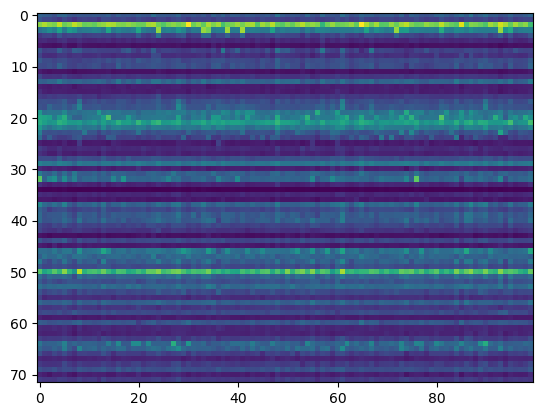

In [68]:
plt.imshow((oracle_stims @ A.T + (720 / 120) * b).T, aspect='auto', interpolation='nearest')


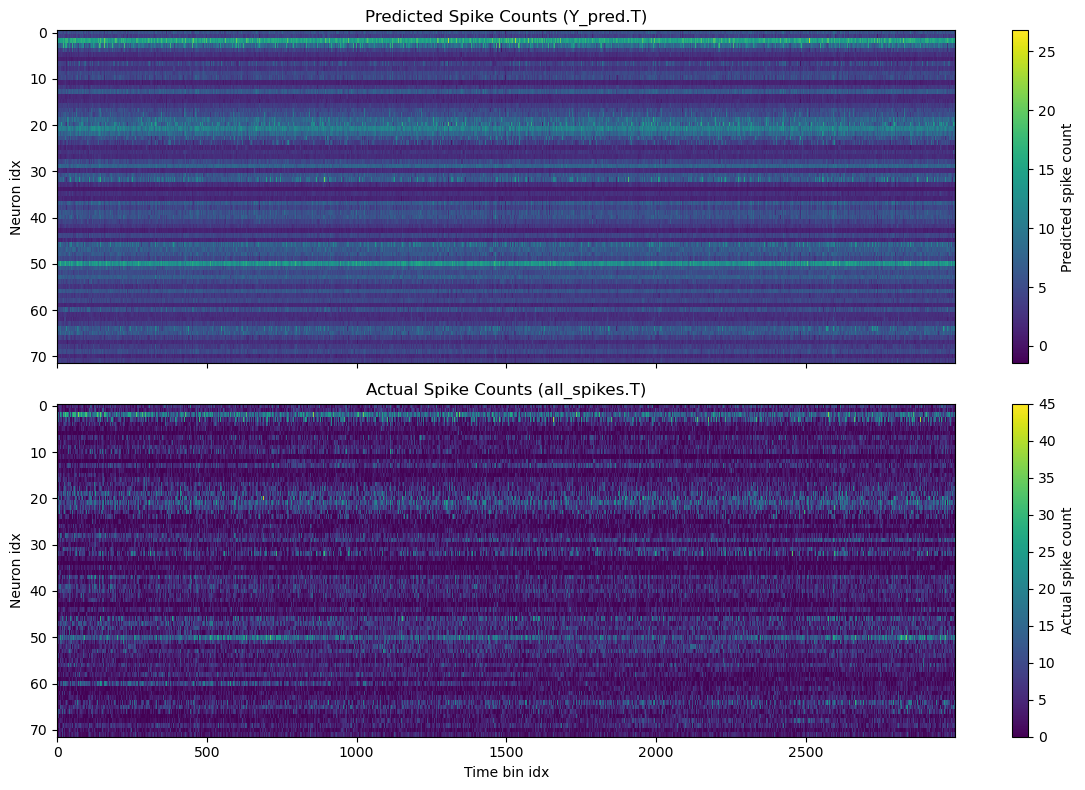

In [18]:
f, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].imshow(Y_pred.T, aspect='auto', interpolation='nearest')
ax[0].set_title("Predicted Spike Counts (Y_pred.T)")
ax[0].set_ylabel("Neuron idx")
ax[1].imshow(all_spikes.T, aspect='auto', interpolation='nearest')
ax[1].set_xlabel("Time bin idx")
ax[1].set_ylabel("Neuron idx")
ax[1].set_title("Actual Spike Counts (all_spikes.T)")
plt.tight_layout()
plt.colorbar(ax[0].images[0], ax=ax[0], label='Predicted spike count')
plt.colorbar(ax[1].images[0], ax=ax[1], label='Actual spike count')
plt.show()

In [178]:
reg = LinearRegression(fit_intercept=False).fit(all_stims, all_spikes)
fcnet = nn.Sequential(nn.Linear(all_stims.shape[1], all_spikes.shape[1], bias=False),
                      nn.ReLU(),
                    nn.Linear(all_spikes.shape[1], all_spikes.shape[1], bias=False)
                      )
adam = torch.optim.Adam(fcnet.parameters(), lr=0.001)
for _ in range(10000):
    outputs = fcnet(torch.from_numpy(all_stims).float())
    loss = nn.MSELoss()(outputs, torch.from_numpy(all_spikes).float())
    loss.backward()
    adam.step()
    adam.zero_grad()

Y_pred_lr = reg.predict(all_stims)
Y_pred_nn = fcnet(torch.from_numpy(all_stims).float()).detach().numpy()

# 2. Calculate R^2 for each neuron
# multioutput='raw_values' returns an array of R^2 scores, one per neuron


r2_values_lr = r2_score(all_spikes, Y_pred_lr, multioutput='raw_values')
mse_values_lr = mean_squared_error(all_spikes, Y_pred_lr, multioutput='raw_values')

r2_values_nn = r2_score(all_spikes, Y_pred_nn, multioutput='raw_values')
mse_values_nn = mean_squared_error(all_spikes, Y_pred_nn, multioutput='raw_values')
print ("Linear Model")
print(f"Average R^2 across all neurons: {np.mean(r2_values_lr):.4f}")
print(f"Average MSE across all neurons: {np.mean(mse_values_lr):.4f}")
print (" ")
print ("Neural Network")
print(f"Average R^2 across all neurons: {np.mean(r2_values_nn):.4f}")
print(f"Average MSE across all neurons: {np.mean(mse_values_nn):.4f}")


Linear Model
Average R^2 across all neurons: 0.5860
Average MSE across all neurons: 1.5170
 
Neural Network
Average R^2 across all neurons: 0.5854
Average MSE across all neurons: 1.5174


Text(0, 0.5, 'batches (averaged over trials)')

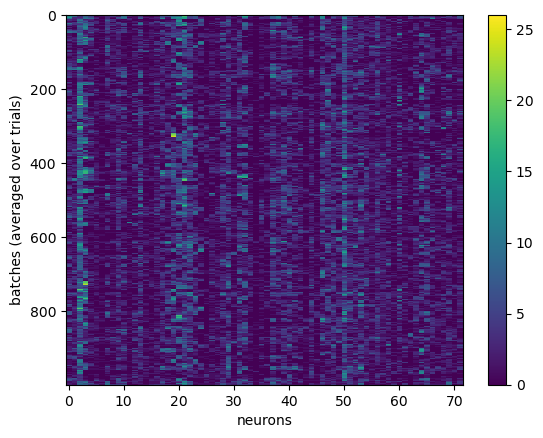

In [179]:
plt.imshow(all_spikes, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.xlabel('neurons')
plt.ylabel('batches (averaged over trials)')

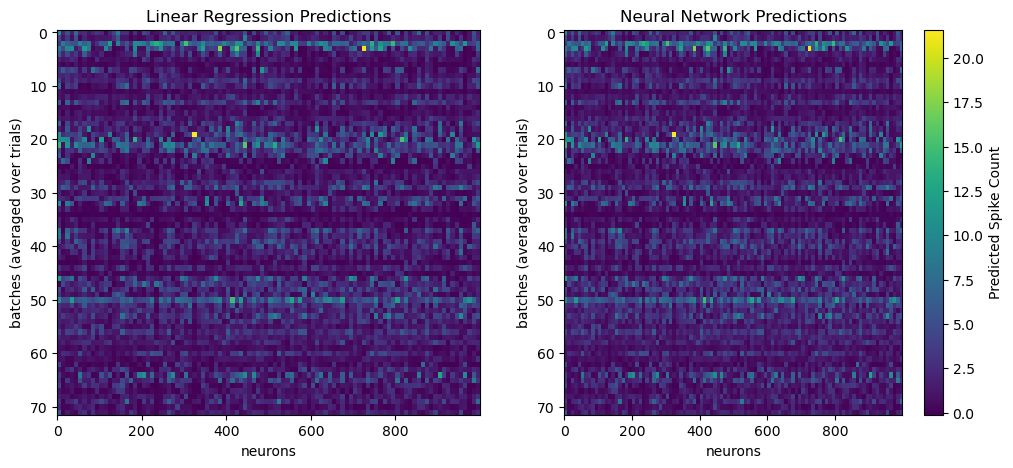

In [182]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(Y_pred_lr.T, aspect='auto', interpolation='nearest')
ax[0].set_title("Linear Regression Predictions")
ax[0].set_xlabel("neurons")
ax[0].set_ylabel("batches (averaged over trials)")
ax[1].imshow(Y_pred_nn.T, aspect='auto', interpolation='nearest')
ax[1].set_title("Neural Network Predictions")
ax[1].set_xlabel("neurons")
ax[1].set_ylabel("batches (averaged over trials)")
plt.colorbar(ax[1].images[0], ax=ax[1], label='Predicted Spike Count')
plt.show()  


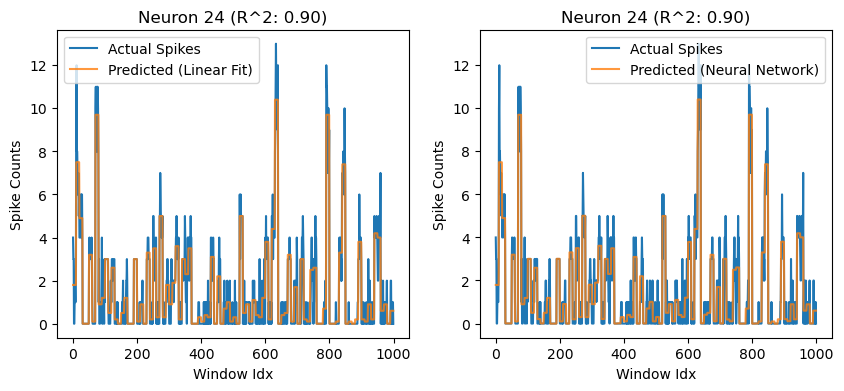

In [183]:
import matplotlib.pyplot as plt

best_neuron = np.argmax(r2_values_lr)
selected_neuron = best_neuron
f, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(all_spikes[:, selected_neuron], label='Actual Spikes')
ax[0].plot(Y_pred_lr[:, selected_neuron], label='Predicted (Linear Fit)', alpha=0.8)
ax[0].set_title(f"Neuron {selected_neuron} (R^2: {r2_values_lr[selected_neuron]:.2f})")

ax[1].plot(all_spikes[:, selected_neuron], label='Actual Spikes')
ax[1].plot(Y_pred_nn[:, selected_neuron], label='Predicted (Neural Network)', alpha=0.8)
ax[1].set_title(f"Neuron {selected_neuron} (R^2: {r2_values_nn[selected_neuron]:.2f})")

ax[0].set_xlabel("Window Idx")
ax[0].set_ylabel("Spike Counts")
ax[1].set_xlabel("Window Idx")
ax[1].set_ylabel("Spike Counts")
ax[0].legend()
ax[1].legend()
plt.show()

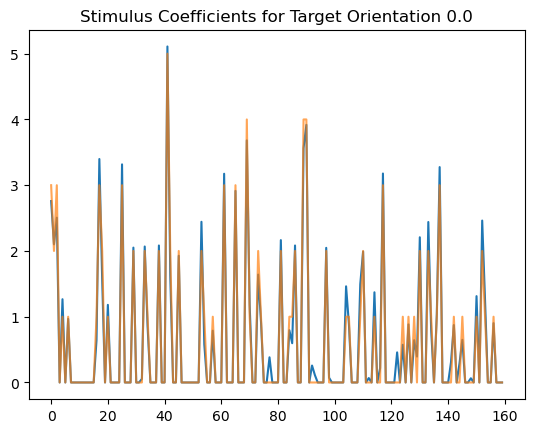

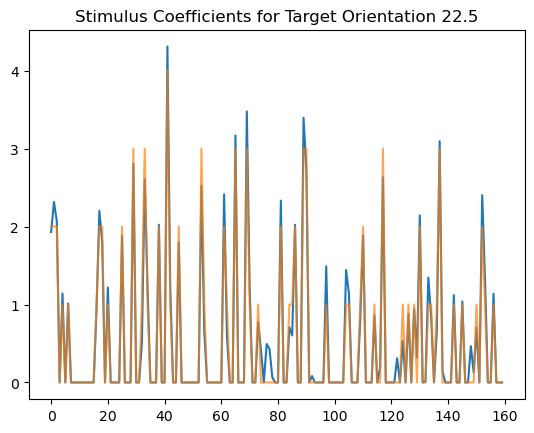

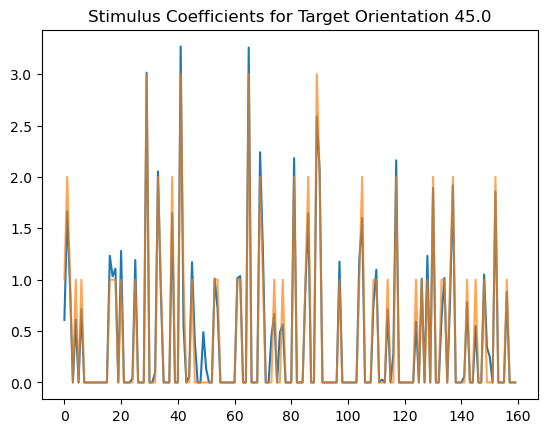

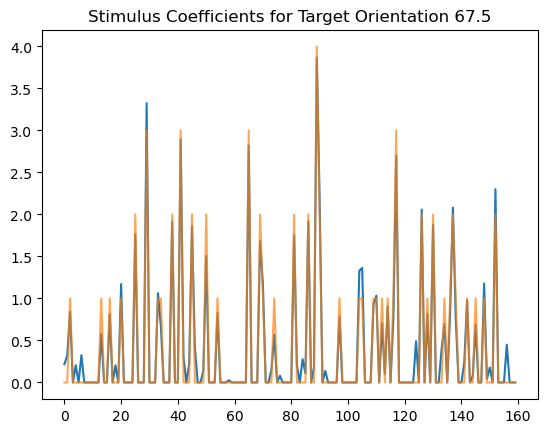

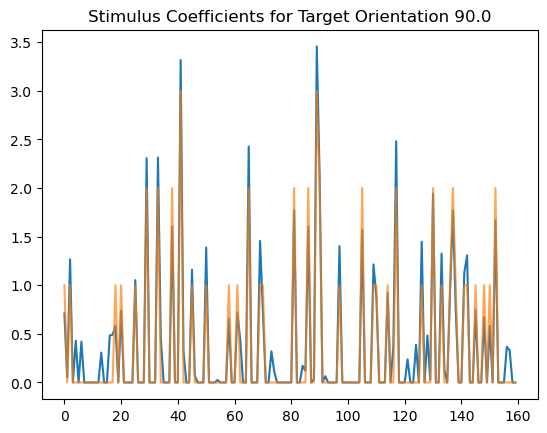

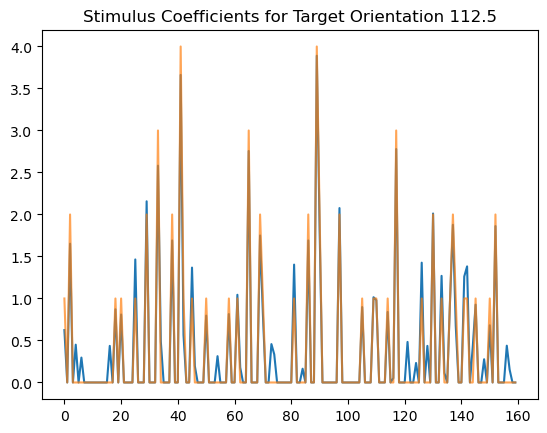

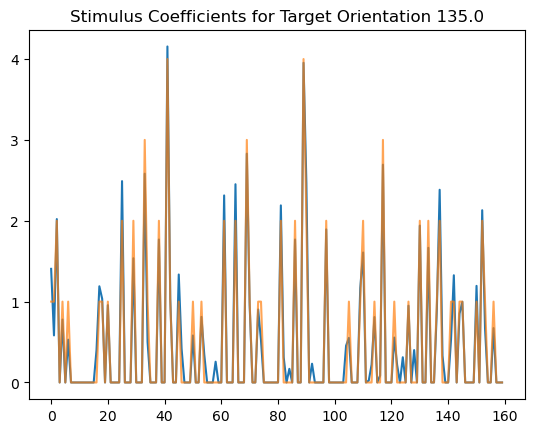

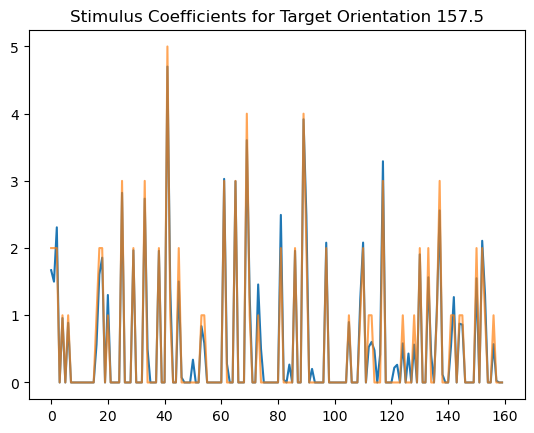

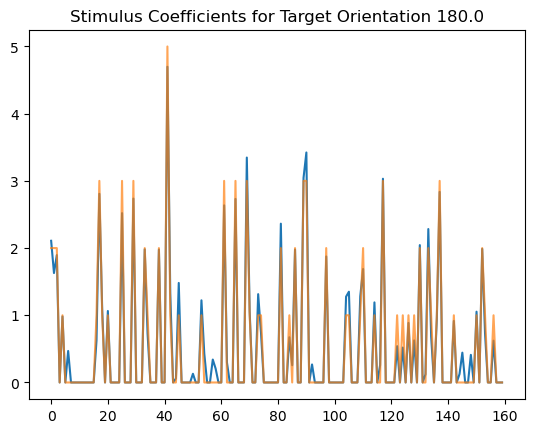

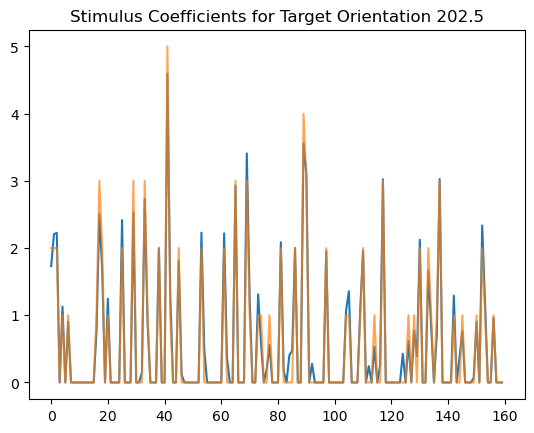

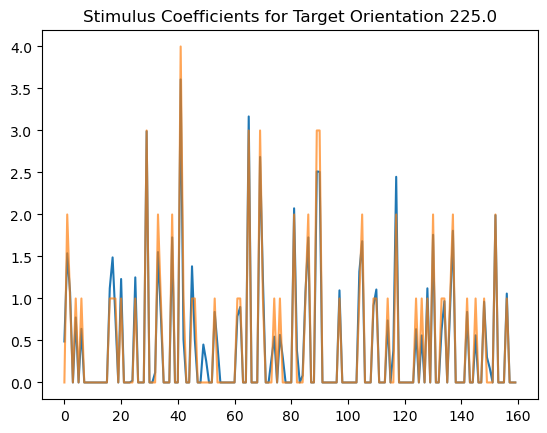

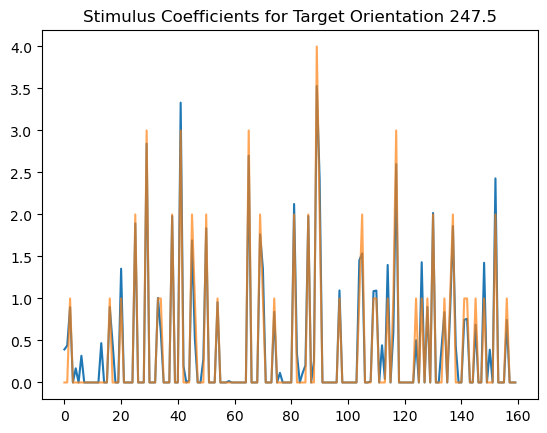

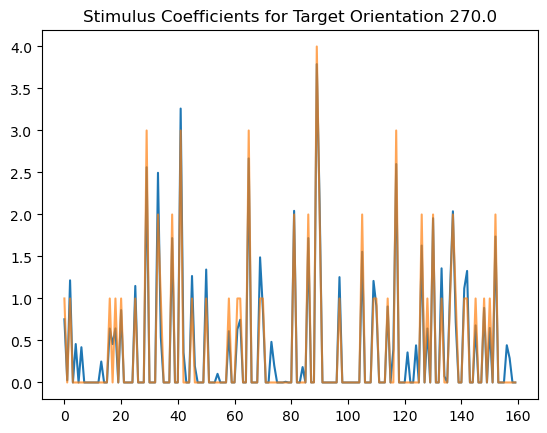

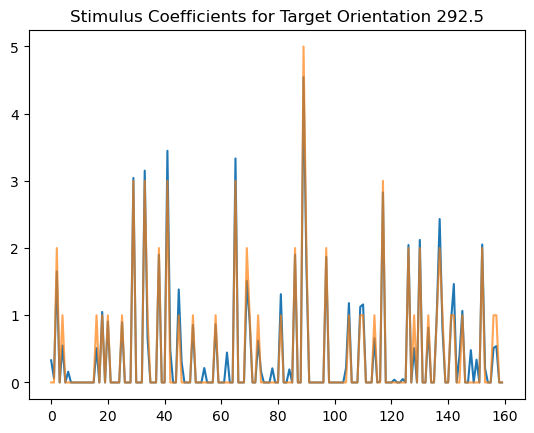

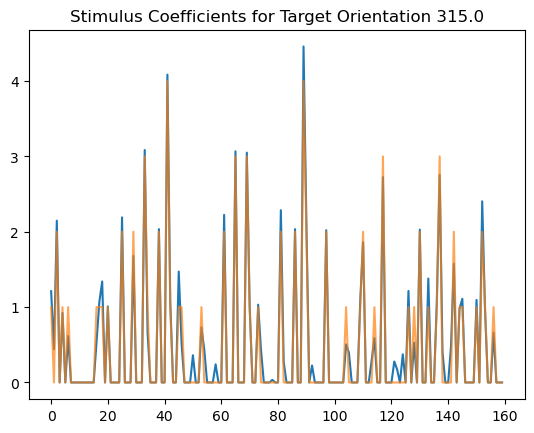

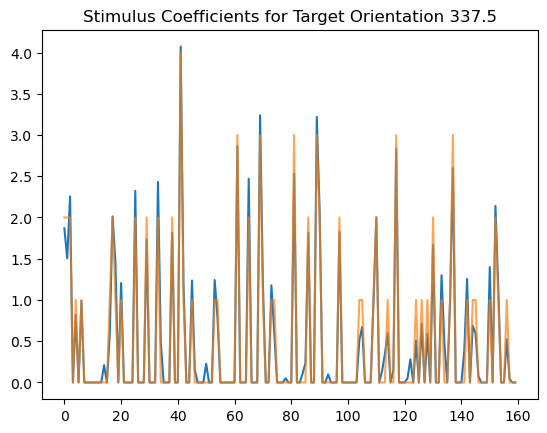

In [195]:
import cvxpy as cp
class NNLS_Controller:
    def compute_stimulus(self, sta_matx, target_response, weight=None, l1=0.0):
        n_patterns = sta_matx.shape[1]
        x = cp.Variable(n_patterns, nonneg=True)
        A = (weight @ sta_matx) if weight is not None else sta_matx
        b = (weight @ target_response) if weight is not None else target_response
        objective = cp.Minimize(cp.sum_squares(A @ x - b) + l1 * cp.norm1(x))
        cp.Problem(objective).solve(solver=cp.OSQP, verbose=False)
        return x.value, np.linalg.norm(sta_matx @ x.value - target_response)
controller = NNLS_Controller()

approx = []
stim_coeffs = []
for itarg in range(16):
    target = sum_responses[itarg, :, :].sum(axis=-1)
    coeffs, err = controller.compute_stimulus(reg.coef_, target, weight=None, l1=1e-3)
    stim_coeffs.append(coeffs)
    plt.plot(coeffs)
    plt.plot(np.round(coeffs), alpha=0.7)
    plt.title("Stimulus Coefficients for Target Orientation {}".format(visual_orientation_degs[itarg]))
    plt.show()
    approx += [proj.T @ reg.coef_ @ np.round(np.round(coeffs))]

approx = np.array(approx)

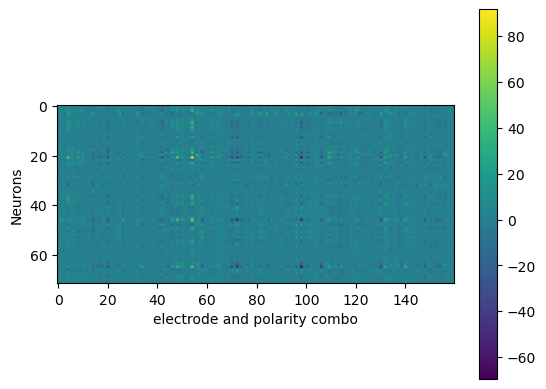

In [196]:
plt.imshow(reg.coef_)
plt.ylabel('Neurons')
plt.xlabel('electrode and polarity combo')
plt.colorbar()

In [197]:
# 1. Did the fit cell rerun after the encoder fix?
print('reg.coef_:', reg.coef_.shape, '  all_stims:', all_stims.shape, '  all_spikes:', all_spikes.shape)
print('R^2 (linear):', np.mean(r2_values_lr))

# 2. Does the model predict well on its own training data for an oracle pattern?
i = 0
print('Y true [first oracle pattern, first 5 neurons]:', all_spikes[i, :5])
print('Y pred:', Y_pred_lr[i, :5])

# 3. What does "approx" look like vs the visual targets it's trying to hit?
print('target shape:', sum_responses[0].sum(-1).shape, 'approx shape:', approx.shape)
print('target[0] norm:', np.linalg.norm(proj.T @ sum_responses[0].sum(-1)))
print('approx[0] norm:', np.linalg.norm(approx[0]))

# 4. Distribution of coeffs after rounding
for i in range(16):
    print(f'orient {i}: round-coeffs nonzero = {(np.round(stim_coeffs[i]) > 0).sum()}, total stims = {int(np.round(stim_coeffs[i]).sum())}')


reg.coef_: (72, 160)   all_stims: (1000, 160)   all_spikes: (1000, 72)
R^2 (linear): 0.5859609727195468
Y true [first oracle pattern, first 5 neurons]: [7. 4. 4. 8. 9.]
Y pred: [11.1  4.8  3.4  8.9  6.1]
target shape: (72,) approx shape: (16, 3)
target[0] norm: 31.60473839097935
approx[0] norm: 59.24016637340698
orient 0: round-coeffs nonzero = 53, total stims = 98
orient 1: round-coeffs nonzero = 53, total stims = 88
orient 2: round-coeffs nonzero = 51, total stims = 71
orient 3: round-coeffs nonzero = 41, total stims = 64
orient 4: round-coeffs nonzero = 38, total stims = 54
orient 5: round-coeffs nonzero = 38, total stims = 60
orient 6: round-coeffs nonzero = 48, total stims = 75
orient 7: round-coeffs nonzero = 48, total stims = 87
orient 8: round-coeffs nonzero = 49, total stims = 85
orient 9: round-coeffs nonzero = 49, total stims = 88
orient 10: round-coeffs nonzero = 50, total stims = 73
orient 11: round-coeffs nonzero = 42, total stims = 65
orient 12: round-coeffs nonzero = 42

In [265]:


fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))


fig.add_trace(go.Scatter3d(
    x=approx[:, 0], y=approx[:, 1], z=approx[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', symbol='diamond',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
))


fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)


In [278]:
stim_set_per_orientation = {}
THRESH = 0.5  # min coefficient to include

# Inverse of the encoder map delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}
LRIDX_TO_DELAY_MODE = {0: -1, 1: 0, 2: 1, 3: 2}

for ori_idx, coeff in enumerate(stim_coeffs):
    entries = []
    if MODE == "step":
        for idx in np.where(coeff > THRESH)[0]:
            ch = idx // 4
            delay_mode = LRIDX_TO_DELAY_MODE[idx % 4]
            entries.append((int(ch), int(delay_mode), float(coeff[idx])))
    else:
        for idx in np.where(coeff > THRESH)[0]:
            ch = idx // n_amplitudes
            amp_val = -3 if (idx % n_amplitudes) == 0 else 3
            entries.append((int(ch), amp_val, float(coeff[idx])))
    entries.sort(key=lambda t: (t[0], t[1]))  # by channel, then delay_mode/amp
    stim_set_per_orientation[ori_idx] = entries


In [279]:
for stim_set in stim_set_per_orientation.values():
    print (stim_set)    
    

[(0, -1, 4.640203241987136), (0, 0, 2.6757635408528713), (1, -1, 0.771720367639983), (1, 1, 4.568007095565148), (3, 0, 3.5680608788617407), (3, 1, 1.8180377352410875), (4, 1, 0.8983365093940399), (5, 0, 1.2843247378304532), (5, 1, 2.5091789832139457), (6, 1, 0.7511786927209778), (8, -1, 1.8151491857992417), (8, 0, 3.856162020021355), (8, 1, 2.6123268296909865), (9, 1, 1.8938396265805977), (10, 1, 1.7719364419023644), (12, 0, 3.6460573476381013), (13, 0, 3.714073246953251), (13, 1, 4.6509830616755155), (14, -1, 1.6307128766721062), (14, 0, 2.0444453276054677), (15, 0, 5.697529711003129), (16, 0, 2.2015401447126597), (17, 0, 3.2152781007734723), (18, 0, 3.0498509996136893), (20, 1, 2.1389032041515534), (21, 1, 1.5851403684623366), (22, -1, 0.6698928851894639), (22, 0, 1.064742713292529), (22, 1, 1.5707731744435327), (23, 0, 1.8206931781790983), (23, 1, 0.6715099826279965), (24, -1, 1.6935751334902311), (24, 1, 1.3187823700953272), (25, 0, 2.2692746438762903), (25, 1, 1.7982273242377724),

In [290]:
# ============================================================
# Build pattern registrations (inverse of read_pattern_json) from
# stim_set_per_orientation, save to generated_pattern_registration.pkl,
# and validate the structure round-trips through read_pattern_json.
#
# K_TRIALS controls how many trials per unique pattern. Each trial gets a
# distinct pattern_timing_index; trials are shuffled across the file so
# trials of the same pattern do not appear contiguously.
# ============================================================
import pickle
import copy
import itertools
import numpy as np
from collections import defaultdict, deque, Counter

if MODE != 'step':
    raise NotImplementedError('Pattern generation currently only supports MODE == step')

K_TRIALS = 10        # trials per unique pattern
SHUFFLE_SEED = 0     # for reproducibility of pattern_timing_index ordering

# Encoder writes stim_one_hot[ch*4 + delay_mode_to_lridx[delay_mode], step] = 1
# with delay_mode_to_lridx = {-1: 0, 0: 1, 1: 2, 2: 3}.  Clean inverse:
lridx_to_delay_mode = {0: -1, 1: 0, 2: 1, 3: 2}
index_to_channel = {idx: ch for ch, idx in channel_to_index.items()}
STEP_MS = 60
n_steps = MAX_TIME_MS // STEP_MS

# ---- Hardware grouping: sort real channel IDs, split into N_GROUPS equal parts.
# Each step may activate at most MAX_PER_GROUP channels from any one group.
N_GROUPS = 4
MAX_PER_GROUP = 4
sorted_real_channels = sorted(channel_to_index.keys())
# group_of[electrode_idx] = which sorted-quartile group this electrode belongs to
group_of = {}
for g in range(N_GROUPS):
    lo = (g * len(sorted_real_channels)) // N_GROUPS
    hi = ((g + 1) * len(sorted_real_channels)) // N_GROUPS
    for real_ch in sorted_real_channels[lo:hi]:
        group_of[channel_to_index[real_ch]] = g
print(f'Hardware groups (real channel IDs):')
for g in range(N_GROUPS):
    members = [c for c in sorted_real_channels if group_of[channel_to_index[c]] == g]
    print(f'  group {g}: {len(members)} channels  range=[{members[0]}, {members[-1]}]')

def feature_idx_to_ch_dm(feat_idx):
    return feat_idx // 4, lridx_to_delay_mode[feat_idx % 4]

def distribute_round_robin(items, n_steps):
    '''Place events into steps subject to:
       (1) at any step, each electrode (channel) is used at most once
           (no two encodings of the same electrode in the same step), and
       (2) at any step, at most MAX_PER_GROUP electrodes from any one
           hardware-quartile group are stimulated.
    '''
    queues = defaultdict(deque)
    for ch, dm, cnt in items:
        for _ in range(int(cnt)):
            queues[(ch, dm)].append((ch, dm))
    total = sum(len(q) for q in queues.values())
    if total == 0:
        return [[] for _ in range(n_steps)]

    # Pre-feasibility: each group has at most MAX_PER_GROUP * n_steps slots.
    group_demand = Counter()
    for (ch, dm), q in queues.items():
        group_demand[group_of[ch]] += len(q)
    for g, d in group_demand.items():
        cap = MAX_PER_GROUP * n_steps
        if d > cap:
            raise ValueError(f'group {g} requires {d} events but only {cap} slots available '
                             f'({MAX_PER_GROUP} per step x {n_steps} steps)')

    placement = [[] for _ in range(n_steps)]
    used_ch_per_step = [set() for _ in range(n_steps)]
    used_group_count = [Counter() for _ in range(n_steps)]
    last_step_for_key = {}
    placed = 0

    while placed < total:
        progressed = False
        for s in range(n_steps):
            # candidates: (ch,dm) queues that still have items, and that satisfy both constraints in this step
            candidates = []
            for k, q in queues.items():
                if not q:
                    continue
                ch = k[0]
                if ch in used_ch_per_step[s]:
                    continue                                # constraint (1)
                if used_group_count[s][group_of[ch]] >= MAX_PER_GROUP:
                    continue                                # constraint (2)
                candidates.append(k)
            if not candidates:
                continue
            # heuristic: longest queue first; break ties by max gap since last placement.
            candidates.sort(key=lambda k: (-len(queues[k]),
                                           -(s - last_step_for_key.get(k, -10**9))))
            chosen = candidates[0]
            ch, dm = chosen
            placement[s].append((ch, dm))
            used_ch_per_step[s].add(ch)
            used_group_count[s][group_of[ch]] += 1
            queues[chosen].popleft()
            last_step_for_key[chosen] = s
            placed += 1
            progressed = True
            if placed == total:
                break
        if not progressed:
            stuck = {k: len(q) for k, q in queues.items() if q}
            raise ValueError(
                f'Cannot place remaining {total - placed} events; stuck queues={stuck}. '
                f'Likely some electrode/group is over capacity even though feasibility passed -- '
                f'try increasing MAX_TIME_MS (more steps) or tightening the controller solve.'
            )
    return [
        [{'channel': int(index_to_channel[ch]), 'delay_mode': int(dm)} for (ch, dm) in placement[s]]
        for s in range(n_steps)
    ]

# Build one canonical pattern dict per orientation (no timing_index yet).
unique_patterns = []
for ori_idx, entries in stim_set_per_orientation.items():
    if any(e[1] in (-3, 3) for e in entries):
        raise NotImplementedError('stim_set_per_orientation looks like pulse-mode; rerun controller in step mode')
    items = [(int(ch), int(dm), int(round(float(cnt)))) for ch, dm, cnt in entries]
    steps_lists = distribute_round_robin(items, n_steps)
    unique_patterns.append({
        'ori_idx': int(ori_idx),
        'pattern_name': f'50{int(ori_idx)}',     # no underscore
        'steps_lists': steps_lists,
    })

# Expand to K_TRIALS copies per pattern, then shuffle to interleave trials.
rng = np.random.default_rng(SHUFFLE_SEED)
trial_slots = [(p['ori_idx'], p['pattern_name']) for p in unique_patterns for _ in range(K_TRIALS)]
order = rng.permutation(len(trial_slots))

generated_patterns = []
for new_pos, slot_idx in enumerate(order):
    ori_idx, pname = trial_slots[slot_idx]
    src = next(p for p in unique_patterns if p['ori_idx'] == ori_idx)
    steps = [
        {'index': step_idx, 'channel_delays': copy.deepcopy(cd), 'start_timestamp': 0}
        for step_idx, cd in enumerate(src['steps_lists'])
    ]
    generated_patterns.append({
        'pattern_name': pname,
        'pattern_lambda': 0.0,
        'pattern_flag_start_timestamp': 0,
        'pattern_timing_index': new_pos + 1,    # 1..N, distinct, in file order
        'steps': steps,
    })

out_path = 'data/generated_pattern_registration.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(generated_patterns, f)
print(f'Wrote {len(generated_patterns)} trials ({len(unique_patterns)} unique patterns x {K_TRIALS}) to {out_path}')

# ---- Structural validation ----
with open(f'{DATADIR}/Combined_Pattern_Registrations.pkl', 'rb') as f:
    ref = pickle.load(f)

ref_keys = set(ref[0].keys())
gen_keys = set(generated_patterns[0].keys())
assert ref_keys == gen_keys, f'top-level keys differ: ref-only={ref_keys-gen_keys}, gen-only={gen_keys-ref_keys}'
ref_step_keys = set(ref[0]['steps'][0].keys())
gen_step_keys = set(generated_patterns[0]['steps'][0].keys())
assert ref_step_keys == gen_step_keys, f'step keys differ: ref-only={ref_step_keys-gen_step_keys}, gen-only={gen_step_keys-ref_step_keys}'
def first_cd(patterns):
    for p in patterns:
        for s in p['steps']:
            if s['channel_delays']:
                return s['channel_delays'][0]
    return None
ref_cd = first_cd(ref); gen_cd = first_cd(generated_patterns)
assert ref_cd is not None and gen_cd is not None, 'no channel_delays found in one of the files'
assert set(ref_cd.keys()) == set(gen_cd.keys()), f'channel_delays keys differ: ref={set(ref_cd.keys())}, gen={set(gen_cd.keys())}'
print('[OK] schema (top / steps / channel_delays) matches Combined_Pattern_Registrations.pkl')

# ---- Sanity on timing indices and trial counts ----
timing_idxs = [p['pattern_timing_index'] for p in generated_patterns]
assert len(set(timing_idxs)) == len(timing_idxs), 'pattern_timing_index values are not distinct'
assert sorted(timing_idxs) == list(range(1, len(generated_patterns) + 1)), 'pattern_timing_index is not 1..N'
assert timing_idxs == sorted(timing_idxs), 'pattern_timing_index is not in file order'
name_counts = Counter(p['pattern_name'] for p in generated_patterns)
assert all(c == K_TRIALS for c in name_counts.values()), f'unequal trial counts per pattern: {name_counts}'

# Longest contiguous run of identical pattern_name in file order.
names_in_order = [p['pattern_name'] for p in generated_patterns]
max_run = max(len(list(g)) for _, g in itertools.groupby(names_in_order))
print(f'[OK] {len(set(timing_idxs))} distinct timing indices (1..{len(generated_patterns)}), '
      f'{K_TRIALS} trials/pattern, longest same-pattern run = {max_run}')

# ---- Hardware-constraint validation: per-step, per-channel and per-group limits.
for p in generated_patterns:
    for s in p['steps']:
        ch_counts = Counter(cd['channel'] for cd in s['channel_delays'])
        if any(v > 1 for v in ch_counts.values()):
            raise AssertionError(f'pattern {p["pattern_name"]} step {s["index"]}: '
                                 f'electrode used multiple times: {ch_counts}')
        grp_counts = Counter(group_of[channel_to_index[cd['channel']]] for cd in s['channel_delays'])
        for g, c in grp_counts.items():
            if c > MAX_PER_GROUP:
                raise AssertionError(f'pattern {p["pattern_name"]} step {s["index"]}: '
                                     f'group {g} used {c} times (max {MAX_PER_GROUP})')
print(f'[OK] hardware constraints: <=1 encoding per electrode per step, '
      f'<={MAX_PER_GROUP} channels per group per step')

# ---- read_pattern_json round-trip ----
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils import read_pattern_json
rt_df = read_pattern_json(out_path)
print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
      f'{rt_df["pattern_timing_index"].nunique()} timing indices, '
      f'{rt_df["pattern_name"].nunique()} unique patterns')

# ---- Per-pattern (electrode, delay_mode) count preservation ----
for ori_idx, entries in stim_set_per_orientation.items():
    expected = Counter()
    for ch, dm, cnt in entries:
        expected[(int(ch), int(dm))] += int(round(float(cnt)))
    expected = Counter({k: v for k, v in expected.items() if v > 0})
    pname = f'50{int(ori_idx)}'
    sample = next(p for p in generated_patterns if p['pattern_name'] == pname)
    rebuilt = Counter()
    for s in sample['steps']:
        for cd in s['channel_delays']:
            ch_idx = channel_to_index[cd['channel']]
            rebuilt[(ch_idx, cd['delay_mode'])] += 1
    assert expected == rebuilt, f'pattern {pname}: expected={expected}  rebuilt={rebuilt}'
print(f'[OK] (electrode, delay_mode) counts preserved across all {len(stim_set_per_orientation)} unique patterns')


Hardware groups (real channel IDs):
  group 0: 10 channels  range=[2, 30]
  group 1: 10 channels  range=[40, 61]
  group 2: 10 channels  range=[66, 91]
  group 3: 10 channels  range=[92, 127]
Wrote 160 trials (16 unique patterns x 10) to data/generated_pattern_registration.pkl
[OK] schema (top / steps / channel_delays) matches Combined_Pattern_Registrations.pkl
[OK] 160 distinct timing indices (1..160), 10 trials/pattern, longest same-pattern run = 2
[OK] hardware constraints: <=1 encoding per electrode per step, <=4 channels per group per step
[OK] read_pattern_json round-trip: 16710 rows, 160 timing indices, 16 unique patterns
[OK] (electrode, delay_mode) counts preserved across all 16 unique patterns


In [291]:
rt_df.head(50)


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_flag_start_timestamp,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial
0,0,0,501,0.0,0,1,12,2,-1,True,1
1,0,0,501,0.0,0,1,12,66,1,True,1
2,0,0,501,0.0,0,1,12,22,-1,True,1
3,0,0,501,0.0,0,1,12,105,0,True,1
4,0,0,501,0.0,0,1,12,3,1,True,1
5,0,0,501,0.0,0,1,12,51,-1,True,1
6,0,0,501,0.0,0,1,12,93,1,True,1
7,0,0,501,0.0,0,1,12,57,0,True,1
8,0,0,501,0.0,0,1,12,98,1,True,1
9,0,0,501,0.0,0,1,12,92,0,True,1


[warn] train rowsum != feat_vec at 34 indices  (feat_sum=130, train_sum=111). First few: [ 0  1  6 13 21]


/var/folders/38/_qz39whn0hngmtsmjg9byfbr0000gn/T/ipykernel_90471/737561028.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 4)


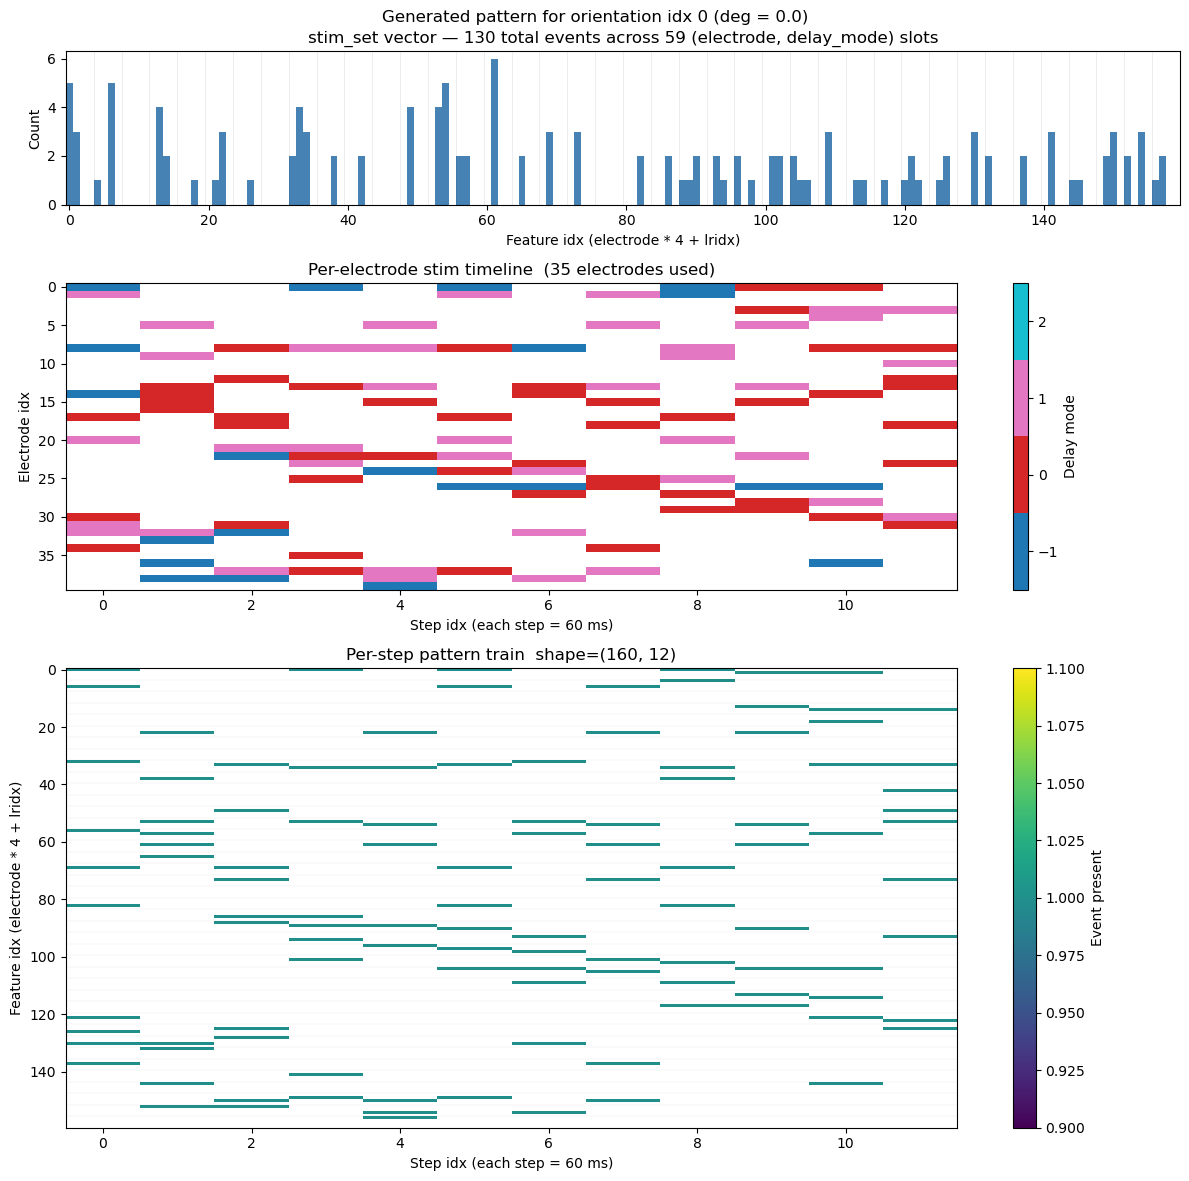


Pattern timing_index=1, n_steps=12
  step  0: ch2/dm-1, ch66/dm1, ch22/dm-1, ch105/dm0, ch3/dm1, ch51/dm-1, ch93/dm1, ch57/dm0, ch98/dm1, ch92/dm0
  step  1: ch13/dm1, ch98/dm1, ch30/dm1, ch109/dm-1, ch53/dm0, ch54/dm0, ch99/dm-1, ch115/dm-1, ch51/dm0, ch49/dm0
  step  2: ch22/dm0, ch113/dm1, ch47/dm0, ch115/dm-1, ch57/dm0, ch74/dm-1, ch98/dm-1, ch72/dm1, ch58/dm0, ch93/dm0
  step  3: ch49/dm0, ch2/dm-1, ch72/dm1, ch113/dm0, ch22/dm1, ch78/dm1, ch107/dm0, ch74/dm0, ch86/dm0
  step  4: ch53/dm0, ch13/dm1, ch74/dm0, ch115/dm1, ch49/dm1, ch82/dm-1, ch127/dm-1, ch22/dm1, ch113/dm1
  step  5: ch57/dm0, ch22/dm0, ch74/dm1, ch66/dm1, ch88/dm-1, ch82/dm0, ch3/dm1, ch113/dm0, ch2/dm-1
  step  6: ch88/dm-1, ch49/dm0, ch78/dm0, ch98/dm1, ch51/dm0, ch82/dm1, ch22/dm-1, ch115/dm1, ch89/dm0
  step  7: ch3/dm1, ch53/dm0, ch86/dm0, ch113/dm1, ch58/dm0, ch88/dm0, ch105/dm0, ch49/dm1, ch13/dm1
  step  8: ch22/dm1, ch57/dm0, ch89/dm0, ch2/dm-1, ch3/dm-1, ch86/dm1, ch30/dm1, ch66/dm1, ch91/dm0
  step  9:

In [292]:
# ============================================================
# Visualize one example: stim_set vector (160 features x count) vs.
# the generated pattern's per-step channel x delay_mode train.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

EXAMPLE_ORI = 0   # which orientation/pattern to visualize
DM_TO_LRIDX = {-1: 0, 0: 1, 1: 2, 2: 3}

entries = stim_set_per_orientation[EXAMPLE_ORI]
pat = generated_patterns[EXAMPLE_ORI]

# 1. Build the 160-d feature vector with integer counts (post-rounding). Use += in case
#    the same (ch, dm) appears more than once in entries.
feat_vec = np.zeros(n_stim_channels * 4, dtype=int)
n_skipped_entries = 0
for ch, dm, cnt in entries:
    lridx = DM_TO_LRIDX.get(int(dm))
    if lridx is None:
        n_skipped_entries += 1
        continue
    feat_vec[int(ch) * 4 + lridx] += int(round(float(cnt)))
if n_skipped_entries:
    print(f'[warn] skipped {n_skipped_entries} entries with unknown delay_mode '
          f'(stale stim_set_per_orientation? rerun the build cell)')

# 2. Build the (n_features, n_steps) train from the generated pattern.
train = np.zeros((n_stim_channels * 4, n_steps), dtype=int)
n_skipped_train = 0
for s_idx, s in enumerate(pat['steps']):
    for cd in s['channel_delays']:
        lridx = DM_TO_LRIDX.get(cd['delay_mode'])
        if lridx is None:
            n_skipped_train += 1
            continue
        ch_idx = channel_to_index[cd['channel']]
        train[ch_idx * 4 + lridx, s_idx] += 1
if n_skipped_train:
    print(f'[warn] skipped {n_skipped_train} pattern entries with unknown delay_mode')

# Sanity (warn rather than assert, so the figure still renders if there's a mismatch).
if not np.array_equal(train.sum(axis=1), feat_vec):
    diff = np.where(train.sum(axis=1) != feat_vec)[0]
    print(f'[warn] train rowsum != feat_vec at {len(diff)} indices  '
          f'(feat_sum={feat_vec.sum()}, train_sum={train.sum()}). First few: {diff[:5]}')

# Per-electrode timeline: rows = electrodes, cols = steps, value = delay_mode used (NaN if empty).
per_ch = np.full((n_stim_channels, n_steps), np.nan)
for s_idx, s in enumerate(pat['steps']):
    for cd in s['channel_delays']:
        per_ch[channel_to_index[cd['channel']], s_idx] = cd['delay_mode']

fig, ax = plt.subplots(3, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1, 2, 3]})
fig.suptitle(f'Generated pattern for orientation idx {EXAMPLE_ORI} '
             f'(deg = {visual_orientation_degs[EXAMPLE_ORI]})')

# (0) feature-vector bar plot
ax[0].bar(np.arange(len(feat_vec)), feat_vec, width=1.0, color='steelblue', edgecolor='none')
for c in range(1, n_stim_channels):
    ax[0].axvline(c * 4 - 0.5, color='k', alpha=0.1, linewidth=0.5)
ax[0].set_xlim(-0.5, len(feat_vec) - 0.5)
ax[0].set_xlabel('Feature idx (electrode * 4 + lridx)')
ax[0].set_ylabel('Count')
ax[0].set_title(f'stim_set vector — {int(feat_vec.sum())} total events across '
                f'{int((feat_vec > 0).sum())} (electrode, delay_mode) slots')

# (1) per-electrode timeline
cmap = plt.cm.get_cmap('tab10', 4)
im_e = ax[1].imshow(per_ch, aspect='auto', interpolation='nearest',
                    cmap=cmap, vmin=-1.5, vmax=2.5)
ax[1].set_xlabel(f'Step idx (each step = {STEP_MS} ms)')
ax[1].set_ylabel('Electrode idx')
n_active_electrodes = int((~np.isnan(per_ch)).any(axis=1).sum())
ax[1].set_title(f'Per-electrode stim timeline  ({n_active_electrodes} electrodes used)')
cb_e = plt.colorbar(im_e, ax=ax[1], ticks=[-1, 0, 1, 2])
cb_e.set_label('Delay mode')

# (2) feature-level train (160 x n_steps)
im = ax[2].imshow(np.where(train > 0, train, np.nan), aspect='auto',
                  interpolation='nearest', cmap='viridis')
ax[2].set_xlabel(f'Step idx (each step = {STEP_MS} ms)')
ax[2].set_ylabel('Feature idx (electrode * 4 + lridx)')
ax[2].set_title(f'Per-step pattern train  shape={train.shape}')
for c in range(1, n_stim_channels):
    ax[2].axhline(c * 4 - 0.5, color='k', alpha=0.1, linewidth=0.3)
plt.colorbar(im, ax=ax[2], label='Event present')

plt.tight_layout()
plt.show()

# Textual step-by-step printout.
print(f'\nPattern timing_index={pat["pattern_timing_index"]}, n_steps={len(pat["steps"])}')
for s in pat['steps']:
    cds = s['channel_delays']
    desc = ', '.join(f"ch{cd['channel']}/dm{cd['delay_mode']}" for cd in cds) if cds else '(empty)'
    print(f'  step {s["index"]:>2}: {desc}')


In [293]:
diff_idx = np.where(train.sum(axis=1) != feat_vec)[0]
print('mismatched feat indices:', diff_idx)
for i in diff_idx[:10]:
    ch, lridx = i // 4, i % 4
    print(f'  feat[{i}] (ch={ch}, lridx={lridx}): feat_vec={feat_vec[i]}, train_rowsum={train.sum(axis=1)[i]}')
print()
print('entries for example pattern:', entries)
print('total feat_vec sum:', feat_vec.sum(), ' train sum:', train.sum())


mismatched feat indices: [  0   1   6  13  21  22  26  42  49  54  56  57  61  65  69  82  89  96
  97 102 104 106 109 117 120 125 126 128 132 141 144 145 154 157]
  feat[0] (ch=0, lridx=0): feat_vec=5, train_rowsum=4
  feat[1] (ch=0, lridx=1): feat_vec=3, train_rowsum=2
  feat[6] (ch=1, lridx=2): feat_vec=5, train_rowsum=3
  feat[13] (ch=3, lridx=1): feat_vec=4, train_rowsum=1
  feat[21] (ch=5, lridx=1): feat_vec=1, train_rowsum=0
  feat[22] (ch=5, lridx=2): feat_vec=3, train_rowsum=4
  feat[26] (ch=6, lridx=2): feat_vec=1, train_rowsum=0
  feat[42] (ch=10, lridx=2): feat_vec=2, train_rowsum=1
  feat[49] (ch=12, lridx=1): feat_vec=4, train_rowsum=2
  feat[54] (ch=13, lridx=2): feat_vec=5, train_rowsum=3

entries for example pattern: [(0, -1, 4.640203241987136), (0, 0, 2.6757635408528713), (1, -1, 0.771720367639983), (1, 1, 4.568007095565148), (3, 0, 3.5680608788617407), (3, 1, 1.8180377352410875), (4, 1, 0.8983365093940399), (5, 0, 1.2843247378304532), (5, 1, 2.5091789832139457), (6, 